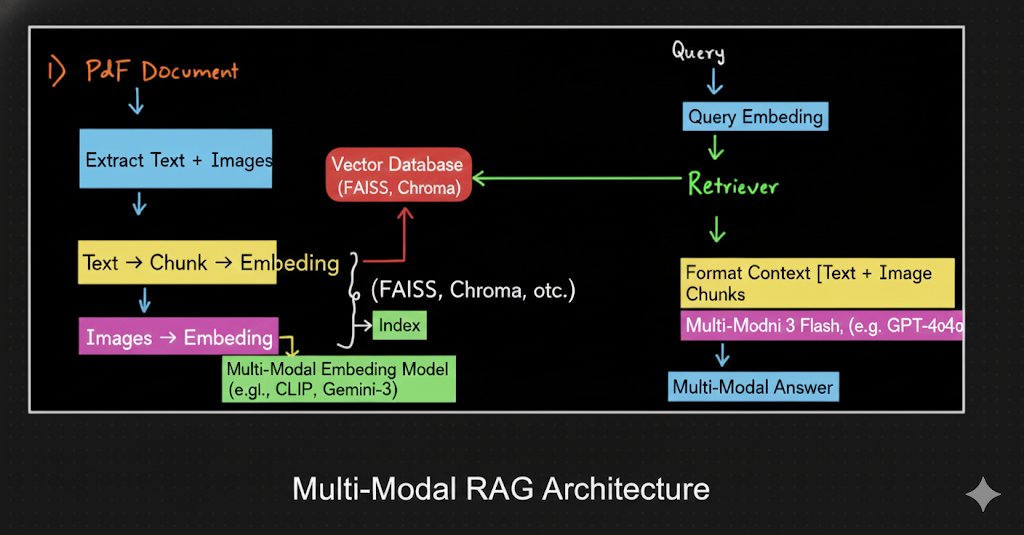

In [1]:
import fitz  # PyMuPDF
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
from sklearn.metrics.pairwise import cosine_similarity
import os
import base64
import io
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS



c:\Users\Deepam Dey\Desktop\MultiModal RAG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
load_dotenv()

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

In [15]:
### CLIP MODEL BY OpenAI
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [16]:
### Create Embeddings for Image and Text

def embed_image(image_data):
    """Embed image using CLIP"""

    if isinstance(image_data, str): ## if image path is given
        image = Image.open(image_data).convert("RGB")
    else: ## If PIL image is given
        image = image_data

    inputs = clip_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        features = clip_model.get_image_features(**inputs)
        #Normalize embeddings to unit vector
        features = features / features.norm(dim = -1, keepdim = True)
        return features.squeeze().numpy()
    
def embed_text(text):
    """Embed text using CLIP."""
    inputs = clip_processor(
        text=text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77  # CLIP's max token length
    )
    with torch.no_grad():
        features = clip_model.get_text_features(**inputs)
        # Normalize embeddings
        features = features / features.norm(dim=-1, keepdim=True)
    return features.squeeze().numpy()



In [17]:
## Read the PDF and Extract texts and images

pdf_path = "indian_car_sales_with_images.pdf"
docs = fitz.open(pdf_path)

## Storage for all documents and embeddings

all_docs = []
all_embeddings = []
image_data_store = {} # stores actual images for LLM

## text splitter

splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 100)

for i, page in enumerate(docs):
    ## text processing
    text = page.get_text()
    if text.strip():
        temp_doc = Document(page_content=text, metadata={"page": i, "type": "text"})
        text_chunks = splitter.split_documents([temp_doc])

        for chunk in text_chunks:
            embedding = embed_text(chunk.page_content)
            all_embeddings.append(embedding)
            all_docs.append(chunk)

## image processing
#  covert pdf to pil format
#  store as base64 for gpt
#  create CLIP embedding for retrieval
for img_index, img in enumerate(page.get_images(full=True)):
    try:
        xref = img[0]
        base_image = docs.extract_image(xref)
        image_bytes = base_image["image"]

        # Convert to PIL Image
        pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        # Create unique identifier
        image_id = f"page_{i}_img_{img_index}"

        # Store image as base64 for later use with GPT-4V
        buffered = io.BytesIO()
        pil_image.save(buffered, format="PNG")
        img_base64 = base64.b64encode(buffered.getvalue()).decode()
        image_data_store[image_id] = img_base64

        # Embed image using CLIP
        embedding = embed_image(pil_image)
        all_embeddings.append(embedding)

        # Create document for image
        image_doc = Document(
            page_content=f"[Image: {image_id}]",
            metadata={"page": i, "type": "image", "image_id": image_id}
        )
        all_docs.append(image_doc)

    except Exception as e:
        print(f"Error processing image {img_index} on page {i}: {e}")
        continue

docs.close()


In [18]:
all_embeddings

[array([ 2.82801334e-02,  1.68798044e-02, -8.61290284e-03, -1.88726261e-02,
        -2.35979613e-02,  1.38887577e-02,  1.18775517e-02,  1.53598756e-01,
         7.41335005e-02, -3.55196781e-02,  7.60756135e-02, -8.14746413e-03,
         1.30291861e-02, -1.33893723e-02,  4.52413969e-02, -4.25663516e-02,
         5.43289371e-02,  1.54777123e-02,  2.78831329e-02,  2.35495511e-02,
         3.42643261e-02,  2.21849997e-02, -8.39272328e-03, -7.01192999e-03,
        -1.13849323e-02,  4.80364598e-02, -1.45694558e-02, -4.98316400e-02,
         3.15478332e-02, -6.37591118e-03,  3.58186290e-02, -6.88196253e-03,
         2.63067824e-03,  1.52788209e-02, -6.16811253e-02, -1.80619359e-02,
         2.10224893e-02, -1.75608005e-02,  5.00171892e-02, -4.04457860e-02,
        -1.65651273e-02,  4.16324325e-02,  1.81963183e-02, -2.12238878e-02,
         1.04610026e-02,  2.14371588e-02,  8.21333099e-03, -1.82849560e-02,
        -1.46783860e-02,  2.53427047e-02, -7.52638746e-03, -1.76893026e-02,
        -2.7

In [19]:
all_docs

[Document(metadata={'page': 0, 'type': 'text'}, page_content='Indian Car Sales Overview\nThis page shows the annual sales volume of popular car models in India. The bar chart below is\nembedded as an image (raster).'),
 Document(metadata={'page': 1, 'type': 'text'}, page_content='Market Share Distribution\nThe pie chart below represents the percentage contribution of each car model to the total sales\nvolume. This chart is embedded as an image (raster).'),
 Document(metadata={'page': 1, 'type': 'image', 'image_id': 'page_1_img_0'}, page_content='[Image: page_1_img_0]')]

In [20]:
# Initialize a FAISS vector index using precomputed document embeddings
# This avoids re-embedding and enables fast similarity search over multimodal data

embeddings_array = np.array(all_embeddings)

vector_store = FAISS.from_embeddings(
    text_embeddings=[
        (doc.page_content, emb)
        for doc, emb in zip(all_docs, embeddings_array)
    ],
    embedding=None,  # Embeddings are already computed (CLIP-based)
    metadatas=[doc.metadata for doc in all_docs]
)


`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [21]:
## Initialize LLM
# from langchain.chat_models import init_chat_model

# llm = init_chat_model("openai:gpt-4.1")
# llm

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview", # Current 2026 model ID
    temperature=0.7
)

llm.invoke("Say hello in one line")


AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'Eo0CCooCAXLI2nzpdgaM0odwhCSZOGp4bXIMUAdUPauYrGU2kvSIweS3e3FI1Cj0gTossRi0b3BLjXDdYCJRCvZxxfvoy1sxKPZkVrhJRKFt0DnPyxSooQWRWKb49Bunnty4vnIaj4gvhlSlls8Q6+l8M0bOqx7XRGG31Fjzjo54hLiHSM26qpbC1bz/qDdMONlvCSRVY5snuIgxXQacpm6LBSVIspQVx1hbb3/V6ebnZSBrYikY8ISQ47sjvpH+rUDlyBzYMdLXo7bbGBOon35YZJqA9TMuVX+pt82eby6H58d8SK1abHhLGS1M33ZfUL1ksUJWFX4UVFygLMwl/9eUtyxS4uTfYIehWHbonmI='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b925b-93e2-7a43-b5d1-e155f588f12e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 81, 'total_tokens': 87, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 72}})

In [22]:
def retrieve_multimodal(query, k=5):
    """Unified retrieval using CLIP embeddings for both text and images"""

    query_embedding = embed_text(query)

    results = vector_store.similarity_search_by_vector(
        embedding=query_embedding,
        k=k # top k
    )
    return results

In [23]:
def create_multimodal_message(query, retrieved_docs):
    """
    Create a multimodal HumanMessage containing:
    - The user query
    - Relevant text context
    - Relevant images (as base64 image URLs)
    
    This message format is compatible with GPT-4V / vision-capable LLMs.
    """

    # This list will hold text blocks and image blocks
    # in the format expected by multimodal chat models
    content = []


    #  Add the user query as the first text block
    content.append({
        "type": "text",
        "text": f"Question: {query}\n\nContext:\n"
    })

    #  Separate retrieved documents by modality
    #    - text documents
    #    - image documents
    text_docs = [
        doc for doc in retrieved_docs
        if doc.metadata.get("type") == "text"
    ]

    image_docs = [
        doc for doc in retrieved_docs
        if doc.metadata.get("type") == "image"
    ]

    #  Add textual context (from PDF text chunks)
    if text_docs:
        # Combine text snippets with page references
        text_context = "\n\n".join([
            f"[Page {doc.metadata['page']}]: {doc.page_content}"
            for doc in text_docs
        ])

        content.append({
            "type": "text",
            "text": f"Text excerpts:\n{text_context}\n"
        })

    #  Add images (encoded as base64 URLs)
    for doc in image_docs:
        image_id = doc.metadata.get("image_id")

        # Ensure the image exists in the image store
        if image_id and image_id in image_data_store:

            # Add a text label describing the image source
            content.append({
                "type": "text",
                "text": f"\n[Image from page {doc.metadata['page']}]:\n"
            })

            # Add the actual image using base64 encoding
            content.append({
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image_data_store[image_id]}"
                }
            })

    #  Add final instruction to guide the LLM
    content.append({
        "type": "text",
        "text": "\n\nPlease answer the question based on the provided text and images."
    })

    #  Return as a LangChain HumanMessage
    return HumanMessage(content=content)


In [24]:
def multimodal_pdf_rag_pipeline(query):
    """
    Main execution pipeline for Multimodal RAG over PDFs.

    Steps:
    1. Retrieve relevant text and image documents
    2. Construct a multimodal prompt (text + images)
    3. Invoke a vision-capable LLM (e.g., GPT-4V)
    4. Print retrieved context for transparency/debugging
    5. Return the model’s final answer
    """

    #  Retrieve relevant multimodal documents(both text chunks and images from the PDF)
    context_docs = retrieve_multimodal(query, k=5)

    #  Create a multimodal message combining:
    #    - User query
    #    - Retrieved text context
    #    - Retrieved images (base64 encoded)
    message = create_multimodal_message(query, context_docs)


    response = llm.invoke([message])

    print(f"\nRetrieved {len(context_docs)} documents:")

    for doc in context_docs:
        doc_type = doc.metadata.get("type", "unknown")
        page = doc.metadata.get("page", "?")

        if doc_type == "text":
            # Show a short preview of the text chunk
            preview = (
                doc.page_content[:100] + "..."
                if len(doc.page_content) > 100
                else doc.page_content
            )
            print(f"- Text from page {page}: {preview}")
        else:
            # Image documents are only referenced by page number
            print(f"- Image from page {page}")

    print("\n")
    return response.content


In [25]:
if __name__ == "__main__":
    queries = [
        "What does the chart on page 1 show about cars sold?",
        "Summarize the main findings from the document.",
        "What visual elements are present in the document?"
    ]

    for idx, query in enumerate(queries, start=1):
        print(f"\nQuery {idx}: {query}")
        print("=" * 60)

        try:
            answer = multimodal_pdf_rag_pipeline(query)
            print("Answer:")
            print(answer)
        except Exception as e:
            print(f"Error while processing query: {e}")

        print("=" * 60)



Query 1: What does the chart on page 1 show about cars sold?

Retrieved 3 documents:
- Text from page 0: Indian Car Sales Overview
This page shows the annual sales volume of popular car models in India. Th...
- Text from page 1: Market Share Distribution
The pie chart below represents the percentage contribution of each car mod...
- Image from page 1


Answer:
[{'type': 'text', 'text': 'Based on the text and the image provided for Page 1, the chart shows the **Sales Percentage Share by Model**, which represents the percentage contribution of each car model to the total sales volume.\n\nSpecifically, it shows the following market shares:\n*   **Maruti Swift:** 22.4%\n*   **Maruti Baleno:** 21.1%\n*   **Hyundai Creta:** 19.9%\n*   **Tata Nexon:** 19.3%\n*   **Kia Seltos:** 17.4%', 'extras': {'signature': 'EvkHCvYHAXLI2nwbYjAgbv8lSn4GYz3CE2BKhvMBFHzXLRFqtPrgakkl+tKX5cKrJNUUH9L8HwtL+QfXWS7QuCK2QEFTBOJqBww6dMdbAXl3QLFyA8J+sNLbvMYE/qILlBebgFNuvmwNRJnM1f/MSWFfP8oGChSXIzKN8D1be0AvFWh9U5X5Shwg